In [1]:
using Plots, LaTeXStrings, Optim, SpecialFunctions, Random,Distributions, Interpolations, Dierckx, NLopt, ForwardDiff, LinearAlgebra, Roots
gr(); #Load packages

In [15]:
function Stochastic(LX,LY,t1,A0,PM) #Stochastic model
T=Int(t1)
Q=Int(sum(A0));
pos = [(0, 0) for _ in 1:Q]
NumAgent= zeros(LX)
    
count = 0
for i in 1:LX
    for j in 1:LY
        if A0[i,j] > 0
        count += 1
        pos[count] = (i,j)
        end
    end
end


for kk in 1:T
Q = length(pos)
count = 0

    while count < Q
        # Choose a random particle to move
        idx = rand(1:Q)
        count = count + 1
        xx, yy = pos[idx]

        # Choose a direction: 1=up, 2=down, 3=left, 4=right
        dir = rand(1:4)
        R=rand(1)
        if dir == 1 && yy < LY && yy >  1 &&  R[1] <= PM
            yy += 1
        elseif dir == 2 && yy < LY && yy >  1 &&  R[1] <= PM
            yy -= 1
        elseif dir == 3 && yy < LY && yy >  1 &&  R[1] <= PM
            xx -= 1
        elseif dir == 4 && yy < LY && yy >  1 &&  R[1] <= PM
            xx += 1
        end

         if dir == 1 && yy == LY  &&  R[1] <= PM
            yy += 0
        elseif dir == 2 && yy == LY  &&  R[1] <= PM
            yy -= 1
        elseif dir == 3  && yy == LY  &&  R[1] <= PM
            xx -= 1
        elseif dir == 4 && yy == LY  &&  R[1] <= PM 
            xx += 1
        end

        if dir == 1 && yy == 1 &&  R[1] <= PM
            yy += 1
        elseif dir == 2  && yy == 1 &&  R[1] <= PM
            yy -= 0
        elseif dir == 3  && yy == 1 &&  R[1] <= PM
            xx -= 1
        elseif dir == 4  && yy == 1 &&  R[1] <= PM
            xx += 1
        end
        
        pos[idx] = (xx, yy)

    end


end




for i in 1:Q
NumAgent[pos[i][1]] = NumAgent[pos[i][1]] + 1    
end

return NumAgent
end

Stochastic (generic function with 1 method)

In [16]:
function loglhood(count,a)  #loglikelihood function 
C(x)=LY*a[1]*(erf((h-x)/sqrt(4*a[2]*T))+erf((h+x)/sqrt(4*a[2]*T)))/2;
ℓ=0.0
ε=1.e-8
for i in 1:LX
λ = max(C(xxloc[i]), ε)
dist = Poisson(λ)
ℓ+=loglikelihood(dist,count[i])
end
return ℓ
end

loglhood (generic function with 1 method)

In [17]:
function Optimise(fun,θ₀,lb,ub) #NLopt routine
    tomax=(θ,∂θ)->fun(θ)
    opt=Opt(:LN_BOBYQA,length(θ₀))
    opt.max_objective=tomax
    opt.lower_bounds=lb      
    opt.upper_bounds=ub
    opt.maxtime=1*60
    res = NLopt.optimize(opt,θ₀)
    return res[[2,1]]
end;

In [18]:
LX=200 #Stochastic simulation and surrogate problem definitions
LY=50
PM=1.0
D=PM/4
T=100.0
U0=0.5
h=25 

A0=zeros(LX,LY)
xxloc=zeros(LX)
yyloc=zeros(LY)
for i in 1:LX
    xxloc[i]=-LX/2+(i-1)
    for j in 1:LY
    R=rand()
    yyloc[j]=0+(j-1)
        if abs(xxloc[i]) <= h && R <= U0
        A0[i,j]=1.0
        end
    end
end

In [19]:
@time data1=Stochastic(LX,LY,T,A0,PM); #Calls the stochastic model, data below is the output used for reproducibility
data = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 2.0, 2.0, 6.0, 1.0, 6.0, 7.0, 5.0, 8.0, 10.0, 4.0, 7.0, 19.0, 11.0, 11.0, 10.0, 19.0, 
    28.0, 19.0, 19.0, 13.0, 23.0, 32.0, 26.0, 23.0, 14.0, 23.0, 15.0, 21.0, 34.0, 19.0, 23.0, 34.0, 28.0, 28.0, 22.0, 23.0, 23.0, 39.0, 19.0, 
    35.0, 25.0, 35.0, 23.0, 20.0, 22.0, 23.0, 20.0, 25.0, 22.0, 24.0, 23.0, 17.0, 26.0, 23.0, 20.0, 27.0, 21.0, 22.0, 26.0, 21.0, 14.0, 12.0,
    7.0, 15.0, 7.0, 11.0, 8.0, 9.0, 2.0, 7.0, 6.0, 4.0, 1.0, 2.0, 1.0, 0.0, 1.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 
    0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0];

  0.116448 seconds (399.25 k allocations: 14.840 MiB, 93.20% compilation time)


In [24]:
length(data)

200

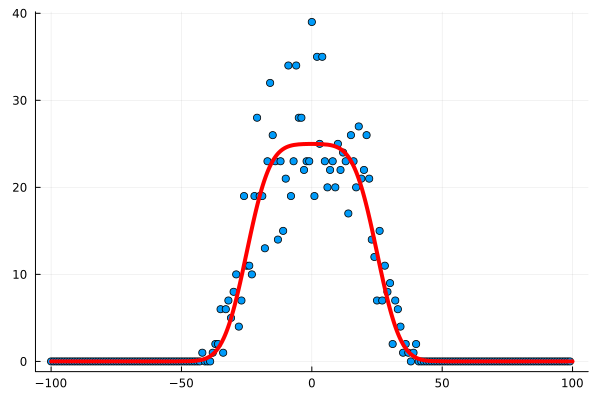

In [21]:
ue(x) = LY*U0*(erf((h-x)/sqrt(4*D*T))+erf((h+x)/sqrt(4*D*T)))/2;
p1 = scatter(xxloc,data,label=false)
p1 = plot!(ue,-LX/2,LX/2,lc=:red,lw=4,label=false) #Create simple plot to compare stochastic simulation data and PDE solution

In [8]:
a=zeros(2)
function funmle(a) #function to call loglikelihood for NLopt
return loglhood(data,a)
end;

  0.467263 seconds (2.12 M allocations: 67.655 MiB, 6.85% gc time, 82.06% compilation time)


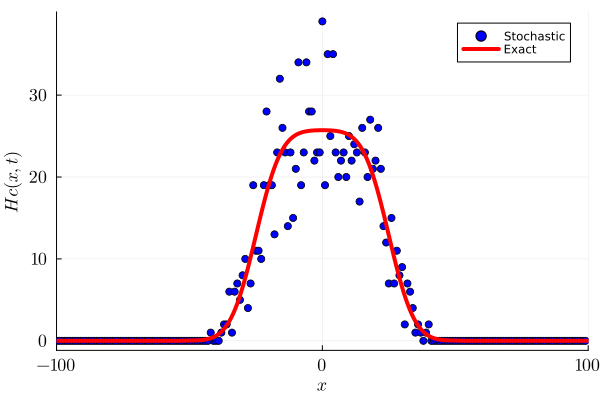

In [9]:
θG=[0.5,0.25]
lb=[0.1,0.01]
ub=[2.0,2.0]
@time (xopt,fopt)=Optimise(funmle,θG,lb,ub)
Umle=xopt[1]
Dmle=xopt[2]
fmle=fopt
C(x)=LY*Umle*(erf((h-x)/sqrt(4*Dmle*T))+erf((h+x)/sqrt(4*Dmle*T)))/2;
p1=scatter(xxloc,data,mc=:blue,msc=:match,label="Stochastic")
p1=plot!(C,-LX/2,LX/2,lw=4,lc=:red,label="Exact",xlabel=L"x",ylabel=L"Hc(x,t)",xlims=(-100,100))
p1=plot!(xticks = ([-100,0,100],  [ L"-100", L"0", L"100" ]))
p1=plot!(yticks = ([0,10,20,30],[L"0", L"10", L"20", L"30"]))
p1=plot!(xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
display(p1) #Computes the MLE and plots data and MLE solution as a visual check

In [10]:
xopt #Print out the MLE 

2-element Vector{Float64}:
 0.5148000008698168
 0.2855160164861793

In [11]:
df=1
llstar=-quantile(Chisq(df),0.95)/2; #Compute the asymptotic threshold loglikelihood value

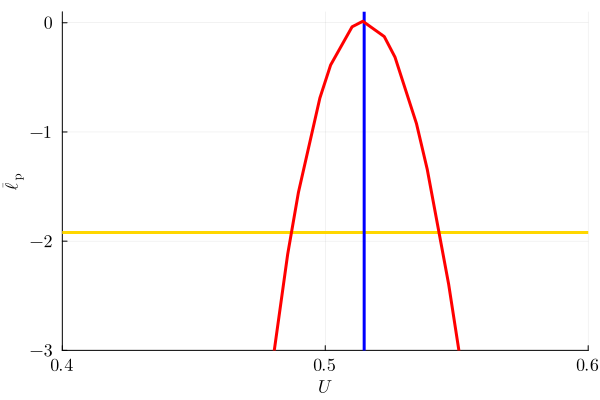

In [12]:
function univariateU(U) #Compute and plot univariate profile loglikelihood for U
    a=zeros(1)    
    function funU(a)
    return loglhood(data,[U,a[1]])
    end
    θG=[Dmle]
    lb=[0.01] 
    ub=[2.0] 
    (xopt,fopt)=Optimise(funU,θG,lb,ub)
    return fopt,xopt
    end 
    f(x) = univariateU(x)[1]

#Take a grid of M points to plot the univariate profile likelihood
M=50;
Urange=LinRange(0.40,0.60,M)
ff=zeros(M)
for i in 1:M
    ff[i]=univariateU(Urange[i])[1]
    #println(i)
end

q1=hline([llstar],legend=false,lw=3,color=:gold)
q1=vline!([Umle],legend=false,xlabel=L"U",ylabel=L"\bar{\ell}_{\textrm{p}}",lw=3,color=:blue)
spl=Spline1D(Urange,ff.-maximum(ff),w=ones(length(Urange)),k=1,bc="nearest",s=1/100)
yy=evaluate(spl,Urange)
q1=plot!(Urange,yy,lw=3,lc=:red,ylims=(-3,0.1),xlims=(Urange[1],Urange[end]))
q1=plot!(xticks=([0.4,0.5,0.6,0.7],[L"0.4", L"0.5", L"0.6",L"0.7"]))
q1=plot!(yticks=([0,-1,-2,-3],[L"0", L"-1", L"-2", L"-3"]))
q1=plot!(xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
display(q1)

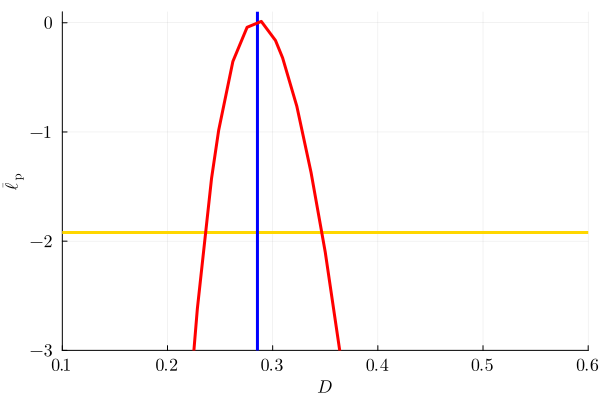

In [13]:
function univariateD(D) #Compute and plot univariate profile loglikelihood for D
    a=zeros(1)    
    function funD(a)
    return loglhood(data,[a[1],D])
    end
    θG=[Umle]
    lb=[0.1] 
    ub=[1.0] 
    (xopt,fopt)=Optimise(funD,θG,lb,ub)
    return fopt,xopt
    end 
    f(x) = univariateD(x)[1]

#Take a grid of M points to plot the univariate profile likelihood
M=75;
Drange=LinRange(0.1,0.6,M)
ff=zeros(M)
for i in 1:M
    ff[i]=univariateD(Drange[i])[1]
  #  println(i)
end

q2=hline([llstar],legend=false,lw=3,color=:gold)
q2=vline!([Dmle],legend=false,xlabel=L"D",ylabel=L"\bar{\ell}_{\textrm{p}}",lw=3,color=:blue)
spl=Spline1D(Drange,ff.-maximum(ff),w=ones(length(Drange)),k=1,bc="nearest",s=1/100)
yy=evaluate(spl,Drange)
q2=plot!(Drange,yy,lw=3,lc=:red,ylims=(-3,0.1),xlims=(Drange[1],Drange[end]))
q2=plot!(xticks=([0,0.1,0.2,0.3,0.4,0.5,0.6],[L"0",L"0.1", L"0.2", L"0.3",L"0.4", L"0.5", L"0.6"]))
q2=plot!(yticks=([0,-1,-2,-3],[L"0", L"-1", L"-2", L"-3"]))
q2=plot!(xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
display(q2)

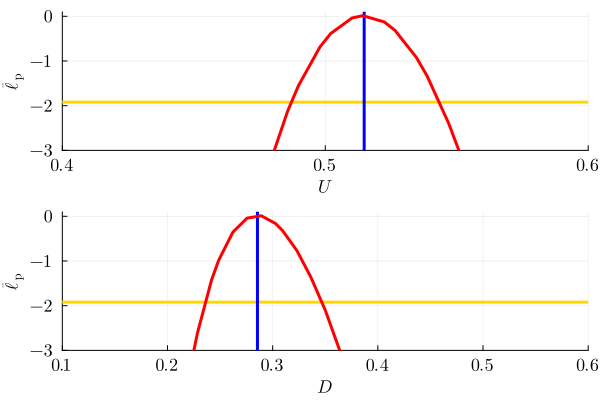

In [14]:
q3=plot(q1,q2,layout=(2,1)) #Figure 5(c)
display(q3)
#savefig(q3,"Profiles.pdf")

In [31]:
xopt

2-element Vector{Float64}:
 0.5148000008698168
 0.2855160164861793

In [32]:
Umin=0.40; Umax=0.60;
Dmin=0.10; Dmax=0.60; #User-defined region about the MLE to sample for the prediction interval computation - computationally expensive approach


df=2
llstar=-quantile(Chisq(df),0.95)/2
M=1000
Usampled=zeros(M)
Dsampled=zeros(M)
lls=zeros(M)
kount = 0

while kount < M
Ug=rand(Uniform(Umin,Umax))
Dg=rand(Uniform(Dmin,Dmax))
    if (loglhood(data,[Ug,Dg])-fmle) >= llstar
    kount+=1
      if mod(kount, 200) == 0
        println("Index: ", kount)
    end
    lls[kount]=loglhood(data,[Ug,Dg])-fmle
    Usampled[kount]=Ug;
    Dsampled[kount]=Dg;
    end

 
end

Index: 200
Index: 400
Index: 600
Index: 800
Index: 1000


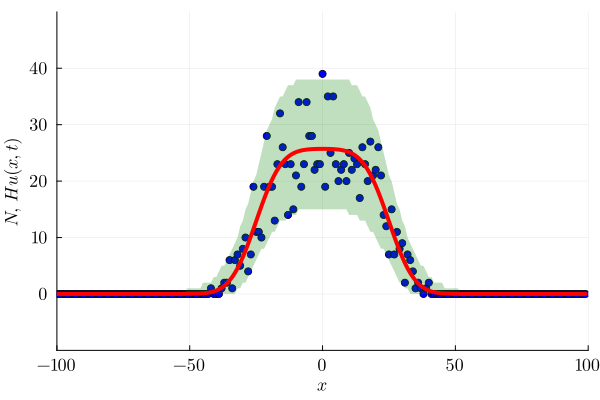

In [33]:
lower1=20*LY*ones(length(xxloc))
upper1=zeros(length(xxloc))


for i in 1:M
#println(i)
C(x)=LY*Usampled[i]*(erf((h-x)/sqrt(4*Dsampled[i]*T))+erf((h+x)/sqrt(4*Dsampled[i]*T)))/2;

    for j in 1:length(xxloc)
        if quantile(Poisson(C(xxloc[j])),[0.025,0.975])[1] < lower1[j] 
            lower1[j] = +quantile(Poisson(C(xxloc[j])),[0.025,0.975])[1]
        end
       
        if quantile(Poisson(C(xxloc[j])),[0.025,0.975])[2] > upper1[j] 
            upper1[j] = quantile(Poisson(C(xxloc[j])),[0.025,0.975])[2]
        end
       
    end

end

C(x)=LY*Umle*(erf((h-x)/sqrt(4*Dmle*T))+erf((h+x)/sqrt(4*Dmle*T)))/2;
r1=scatter(xxloc,data,mc=:blue,msc=:match,label=false)
r1=plot!(xxloc,lower1,lw=0,fillrange=upper1,fillalpha=0.25,color=:green,label=false,xlims=(-100,100),ylims=(-10,50))
r1=plot!(C,xxloc[1],xxloc[end],lw=4,label=false,xlabel=L"x",ylabel=L"N, \, Hu(x,t)",color=:red)
r1=plot!(xticks = ([-100,-50,0,50,100],  [L"-100", L"-50", L"0", L"50", L"100"]))
r1=plot!(yticks = ([0,10,20,30,40],[L"0", L"10", L"20", L"30", L"40"]))
r1=plot!(xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
display(r1) #Prediction intervals computed using rejection sampling - computationally expensive approach

In [34]:
fff(θ1,θ2) = funmle([θ1,θ2]) #Compute the observed Fisher Information at the MLE
H = -ForwardDiff.hessian(z -> fff(z[1],z[2]),xopt)
H = Symmetric(H) #Ensure the matrix is symmetric

2×2 Symmetric{Float64, Matrix{Float64}}:
 4856.25          -3.07974e-6
   -3.07974e-6  1273.49

In [40]:
Σ = inv(H);
mvnorm = MvNormal(xopt, Σ); #MVN distribution to invoke Laplace's approximation
M=1000
samples = rand(mvnorm, M); #Draw parameter samples

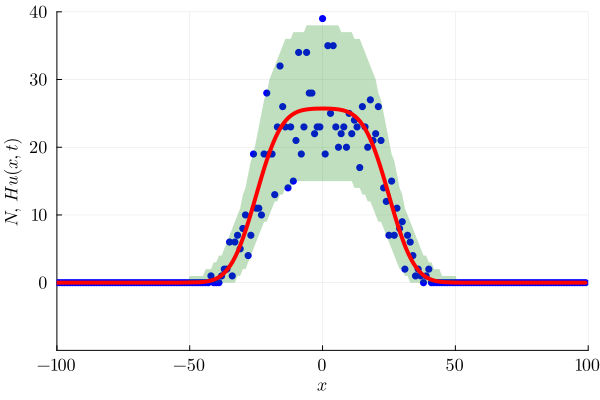

In [42]:
lower2=zeros(length(xxloc))
upper2=zeros(length(xxloc))
q25 = zeros((M, length(xxloc)));
q975 = zeros((M, length(xxloc)));

for i in 1:M
C(x)=LY*samples[1,i]*(erf((h-x)/sqrt(4*samples[2,i]*T))+erf((h+x)/sqrt(4*samples[2,i]*T)))/2;

    for j in 1:length(xxloc)
        q25[i,j] = quantile(Poisson(C(xxloc[j])),0.025)
        q975[i,j] = quantile(Poisson(C(xxloc[j])),0.975)
    end
end

for j in 1:length(xxloc)
    lower2[j] = quantile(q25[:, j], 0.025);
    upper2[j] = quantile(q975[:, j], 0.975);
end

C(x)=LY*Umle*(erf((h-x)/sqrt(4*Dmle*T))+erf((h+x)/sqrt(4*Dmle*T)))/2;
r2=scatter(xxloc,data,mc=:blue,msc=:auto,label=false)
r2=plot!(xxloc,lower2,lw=0,fillrange=upper2,fillalpha=0.25,label=false,color=:green,xlims=(-100,100),ylims=(-10,40))
r2=plot!(C,xxloc[1],xxloc[end],lw=4,label=false,xlabel=L"x",ylabel=L"N, \, H u(x,t)",color=:red)
r2=plot!(xticks = ([-100,-50,0,50,100],  [L"-100", L"-50", L"0", L"50", L"100"]))
r2=plot!(yticks = ([0,10,20,30,40],[L"0", L"10", L"20", L"30", L"40"]))
r2=plot!(xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
display(r2) #Prediction intervals computed using Laplace's approximation - computationally inexpensive approach

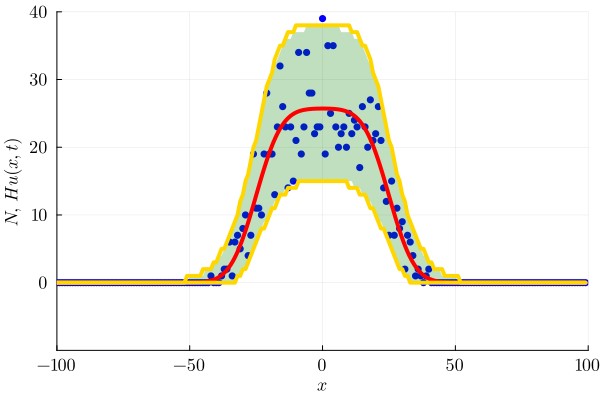

"C:\\Users\\simpsom3\\Dropbox\\RW_Inference_Identifiability_Prediction\\TidyCodes4GitHub\\Fig5d.pdf"

In [43]:
r2=plot!(xxloc,upper1,lc=:gold,lw=4,legend=false)
r2=plot!(xxloc,lower1,lc=:gold,lw=4,legend=false)
display(r2) #Figure 5(d)
savefig(r2,"Fig5d.pdf")

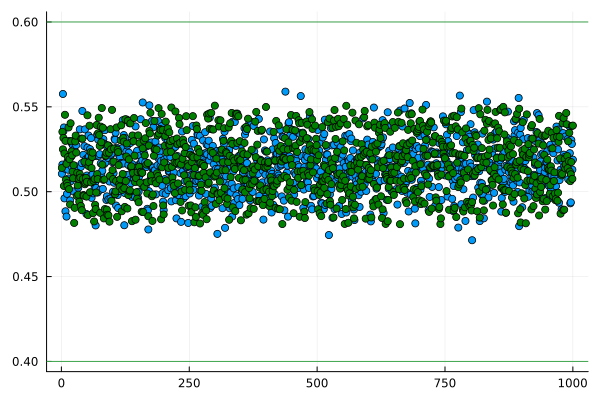

In [28]:
q1=scatter(samples[1,:],legend=false)
q1=scatter!(Usampled,mc=:green,legend=false)
q1=hline!([Umin,Umax],legend=false) #Visual check on the comparison of the two sets of samples for U.
#This is useful to check on the user-specified bounds for the rejection sampling

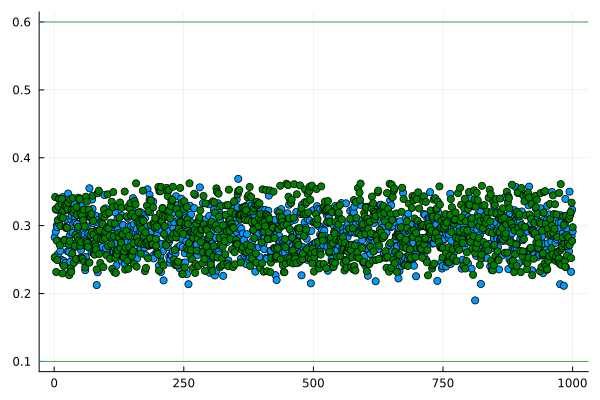

In [29]:
q1=scatter(samples[2,:],legend=false)
q1=scatter!(Dsampled,mc=:green,legend=false)
q1=hline!([Dmin,Dmax],legend=false) #Visual check on the comparison of the two sets of samples for D.
#This is useful to check on the user-specified bounds for the rejection sampling